# 90 Days Violation
## 1.0 not looking at exeptions, just displaying how many appartments are rented for more than 90 days / year

In [2]:
import pandas as pd
listings = pd.read_csv(r"C:\Users\ThinkPad\Desktop\Mastermind\Inside_Airbnb_Berlin\Data\listings.csv")

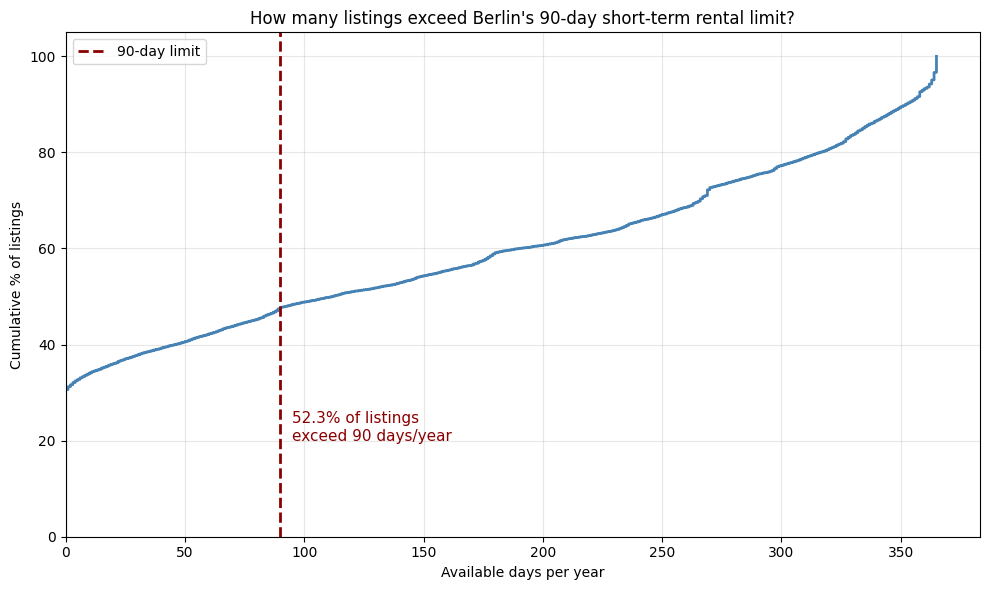

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../Plotting_output/SelmasPlots", exist_ok=True)

avail = listings["availability_365"].dropna().sort_values().values
ecdf = np.arange(1, len(avail) + 1) / len(avail) * 100



plt.figure(figsize=(10, 6))
plt.plot(avail, ecdf, color="steelblue", linewidth=2)

# Berlin's 90-day rule: short-term rentals beyond 90 days/year typically require permits
plt.axvline(90, color="darkred", linestyle="--", linewidth=2, label="90-day limit")

# Find what % of listings are below the line
pct_below_90 = (avail <= 90).mean() * 100
plt.text(95, 20, f"{100 - pct_below_90:.1f}% of listings\nexceed 90 days/year",
         color="darkred", fontsize=11)

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.margins(0)

plt.xlabel("Available days per year")
plt.ylabel("Cumulative % of listings")
plt.title("How many listings exceed Berlin's 90-day short-term rental limit?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Plotting_output/SelmasPlots/availability_ecdf.png", bbox_inches="tight", dpi=150)
plt.show()

## Backgroudn information of the 90 days violation

#### 90-day rule — key facts

* Berlin-specific (via Zweckentfremdungsverbot), not Germany-wide; other cities differ (Munich 56 days, Hamburg bans commercial whole-flats).
* Cap applies to secondary residences: max 90 short-term days/year + permit. Primary residence (where you're registered) has no day cap, just a registration number.
* "Short-term" = under 90 consecutive days. A single 90+ day booking is a normal tenancy, outside the rule.
* Enforced by the Bezirksamt (since March 2026: Fachbereich Stadterneuerung). Fines up to €500,000; both host and platform liable.
* Weak follow-through: of €12.4M fined since 2014, only €4.2M collected, mainly due to staff shortages. May 2026 EU data-sharing law is tightening this.
* Report suspected misuse: https://service.berlin.de/dienstleistung/352954/
* Common evasion: high minimum_nights to look long-term, splitting flats across listings/accounts, missing/shared registration numbers, listing as "private room."

### Data processing ideas (your listings)

* ECDF of availability_365 with 90-day line → share of listings that could exceed the limit (your current plot).
* minimum_nights >= 90 → flag listings posing as long-term.
* license value_counts(dropna=False) → how many lack a registration number.
* host_listings_count / calculated_host_listings_count > 1 → likely secondary/commercial operators.
* calculated_host_listings_count_entire_homes vs _private_rooms → portfolio shape.
* room_type → entire-home = most regulated.
* neighbourhood_group_cleansed → enforcement/concentration by Bezirk.
* Not derivable: true primary-vs-secondary status, and whether a permit is genuinely valid.